# ***CCA (Complete Case Analysis)***

**Basically this approach tells us to include only those cases (rows) in our analysis where all the variables (columns) have valid (non-missing) values and to discard all the observations which have missing variables.**

---

> **Pros:**
> - Simple to implement
> - No need for complex imputation methods
> - Results are unbiased if data is MCAR (Missing Completely at Random)
>
> **Cons:**
> - May lead to loss of information and reduced sample size
> - Can introduce bias if data is not MCAR
> - May result in inefficient use of available data
---

**This approach can be used only in the cases where `less than 5 % data of a col is missing` and `the data is MCAR`**

---

- MCAR means Missing Completely at Random. If the data is not MCAR that means the missingness is related to the observed data or unobserved factors means the missing data is not random and may introduce bias into the analysis.

Ex. - Suppose:

People with low income are more likely to skip income questions

Now you do CCA:

You remove those rows

👉 What happens?

Your dataset now has mostly higher-income people
Your analysis becomes biased


In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('dataset.csv')
data.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [11]:
data.isnull().mean() * 100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [14]:
# CCA can be applied to the cols
permissible_cols = [c for c in data.columns if data[c].isnull().mean() > 0 and data[c].isnull().mean() < 0.05]
permissible_cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

> **If we apply cca approach on this dataset we have only option to analyse with these 5 variables**

In [16]:
new_data = data[permissible_cols].dropna()
new_data

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
4,0.767,no_enrollment,Masters,20.0,8.0
5,0.764,Part time course,Graduate,11.0,24.0
...,...,...,...,...,...
19153,0.878,no_enrollment,Graduate,14.0,42.0
19154,0.920,no_enrollment,Graduate,14.0,52.0
19155,0.920,no_enrollment,Graduate,20.0,44.0
19156,0.802,no_enrollment,High School,0.0,97.0


### ***Check for correctness***

In [ ]:
#  percentage of observations per category in both data must remains almost same

temp = pd.concat([
            # percentage of observations per category, original data
            data['education_level'].value_counts() / len(data),

            # percentage of observations per category, cca data
            new_data['education_level'].value_counts() / len(new_data)
        ],
        axis=1)

# add column names
temp.columns = ['original', 'cca']

temp

,original,cca
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587


<Axes: ylabel='Density'>

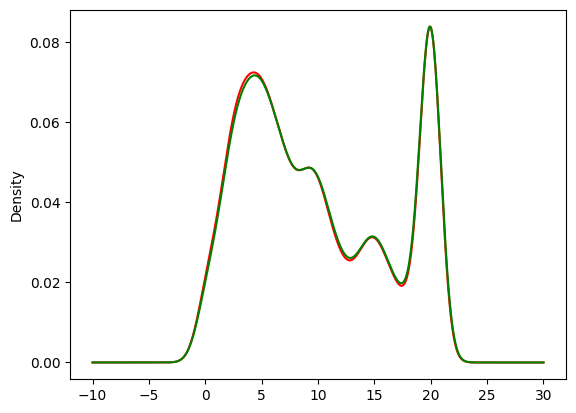

In [18]:
#  distribution of each num col must remains almost same

# original data
data['experience'].plot.density(color='red')

# data after cca
new_data['experience'].plot.density(color='green')

- These 2 checks ultimately prove that data is MCAR. CCA has not made the data biased.